# Employee Turnover Analytics - Data Understanding

## Notebook 1: Understanding the Dataset

In this notebook, we load the employee attrition dataset and perform an initial exploration to understand its structure, data types, missing values, and target variable.

## 1. Import Libraries
We import pandas for data manupulation and numpy for numerical operation

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")  ## loading dataset
df.head() ## display first 5 rows of the dataset

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info() ## display the summary of the dataset

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [7]:
df.isnull().sum() ## check for missing values in the dataset

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df.duplicated().sum() ## check for duplicate values in the dataset

np.int64(0)

In [9]:
df["Attrition"].value_counts() ## check the distribution of the target variable

Attrition
No     1233
Yes     237
Name: count, dtype: int64

# EXPLORATORY DATA ANALYSIS
## Attrition Distribution
We visualize how many employees stayed vs left.

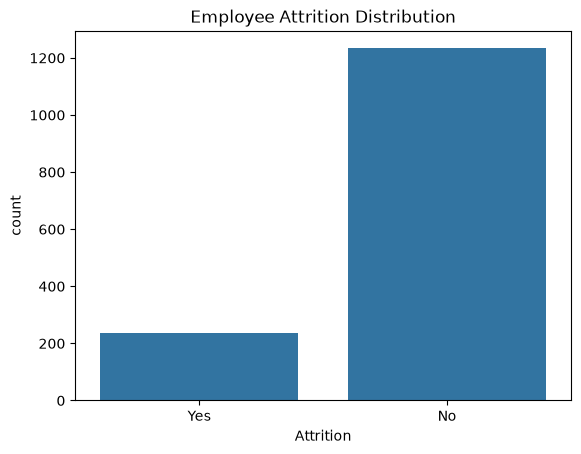

In [11]:
sns.countplot(x = "Attrition", data = df) ## visualize the distribution of the target variable
plt.title("Employee Attrition Distribution")
plt.show()

## Department Vs Attrition
To understand whether employee attrition differs across departments, we compare the number of employees who stayed and left in each department.

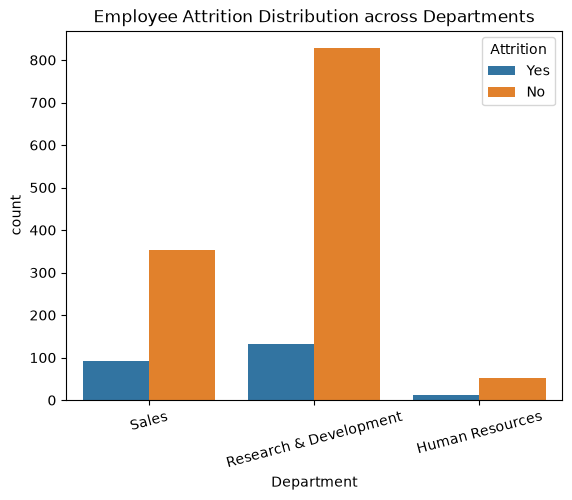

In [12]:
sns.countplot(x= "Department", hue = "Attrition", data = df) ## visualize the distribution of the target variable across departments
plt.title("Employee Attrition Distribution across Departments")
plt.xticks(rotation = 15)
plt.show()

### Analysis

From the chart, the **Research & Development** department has the largest number of employees. It also has the highest number of employees who left the company. However, it also has the highest number of employees who stayed, which is expected because it has the largest workforce.

The **Sales** department has fewer employees than Research & Development but also experiences employee attrition.

The **Human Resources** department has the smallest number of employees and the lowest number of employees leaving the company.

Overall, employee attrition is observed in all departments. Research & Development has the highest number of employees leaving, but this does not necessarily mean it has the highest attrition rate because it also has the largest number of employees.

## Overtime vs Attrition

We analyze whether employees who work overtime are more likely to leave the company compared to those who do not work overtime.

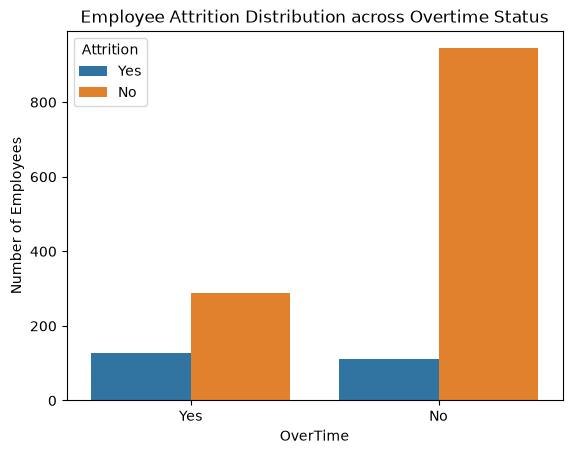

In [14]:
sns.countplot(x= "OverTime", hue = "Attrition", data = df) ## visualize the distribution of the target variable across overtime status)
plt.title("Employee Attrition Distribution across Overtime Status")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()

### Analysis

The graph shows that employees who work overtime have a higher tendency to leave the company compared to those who do not work overtime.

Employees who do not work overtime are more likely to stay, as shown by the significantly larger number of employees in the "No Attrition" category.

This suggests a potential relationship between overtime and employee attrition, which may indicate workload pressure or burnout as contributing factors to employee turnover.

## Monthly Income vs Attrition

We analyze whether employee salary levels influence the likelihood of leaving the company.

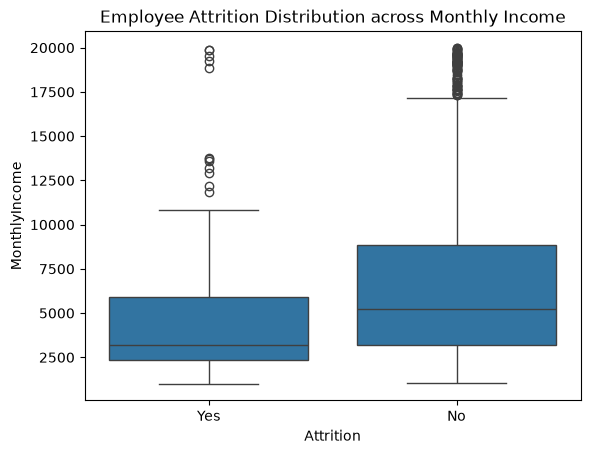

In [16]:
sns.boxplot(x = "Attrition", y = "MonthlyIncome", data = df) ## visualize the distribution of the target variable across monthly income
plt.title("Employee Attrition Distribution across Monthly Income")
plt.show()